In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import lfilter, welch
from scipy.ndimage import uniform_filter1d
from fooof import FOOOF

In [43]:
class PoissonTrainGenerator:

    @classmethod
    def generate_spike_train(cls, inst_firing_rate, fs, random_state):
        t = np.zeros(len(inst_firing_rate))
        for i, lambd in enumerate(inst_firing_rate):
            num_points = random_state.poisson(lambd / fs)
            if num_points > 0: t[i] = 1
        return t
    
def generate_pink_noise(num_obs, random_state):
    white_noise = random_state.normal(1, 0.5, num_obs + 2000)

    A = [1, -2.494956002, 2.017265875, -0.522189400]
    B = [0.049922035, -0.095993537, 0.050612699, -0.004408786]

    pink_noise = lfilter(B, A, white_noise)[2000:]
    pink_noise = (pink_noise - np.min(pink_noise)) / (np.max(pink_noise) - np.min(pink_noise))
    return pink_noise

1. To reproduce the 1/f spectrum that is widely found in neuronal spike trains, the 100 spike trains in each functional
group were modulated by a unique normalized (from 0.5 to 1.5) firing rate time series that had a
1/f spectrum (more slow modulation of firing than fast) that was created by filtering white noise
using standard techniques. 

2. The normalized firing rate time series was then multiplied with the
mean firing rate of each of the 100 pre-synaptic nodes. 

3. Spike trains are then generated by
sampling from a Poisson distribution using the firing rate time series of each presynaptic node of
the functional group.

In [28]:
# 1
rs = np.random.RandomState(123)


firing_rates = []
for _ in range(100):
    # Generate 1/f firing rate time series in (0, 1) and shift to (0.5, 1.5)
    firing_rate_time_series = generate_pink_noise(10000, rs) + 0.5
    firing_rates.append(firing_rate_time_series)

firing_rates = np.array(firing_rates)

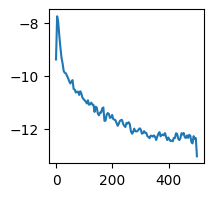

In [29]:
fig, ax = plt.subplots(1, 1, figsize = (2, 2))
f, Pxx = welch(firing_rates[0], fs = 1000)
plt.plot(f, np.log(Pxx)) # ok

In [30]:
# 2

# Generate firing rate of presynaptic nodes and multiply
fr_presyn = np.abs(rs.normal(4.43, 2.9, (100, 1))) # or whichever distribution we use, levy / gamma / etc. would work
firing_rates = firing_rates * fr_presyn

In [50]:
# 3

# Generate spike trains
spike_trains = []
for idx in range(100):
    spike_trains.append(PoissonTrainGenerator.generate_spike_train(firing_rates[idx], 1000, rs))
spike_trains = np.array(spike_trains)

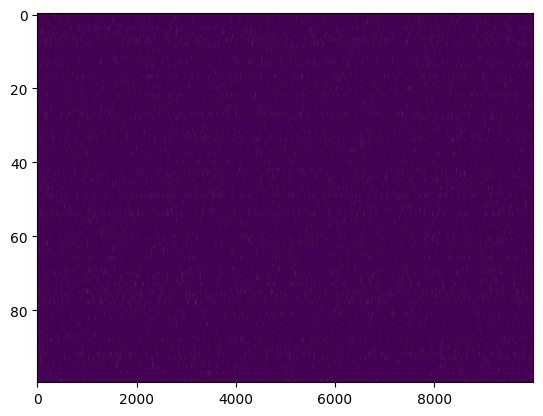

In [51]:
plt.imshow(spike_trains, aspect = 'auto') # ok

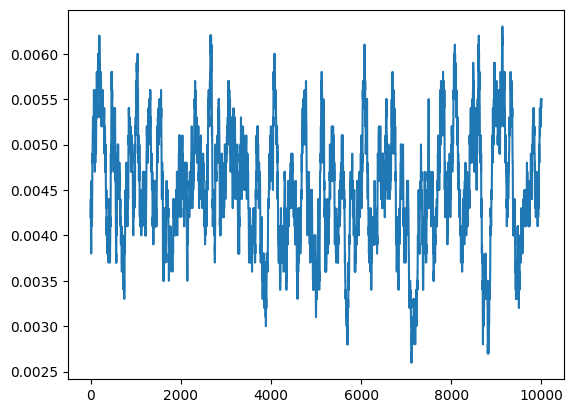

In [80]:
# Check
inst_firing_rate = uniform_filter1d(np.mean(spike_trains, axis = 0), 100)
plt.plot(inst_firing_rate)

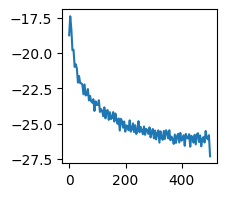

In [82]:
fig, ax = plt.subplots(1, 1, figsize = (2, 2))
f, Pxx = welch(inst_firing_rate, fs = 1000)
plt.plot(f, np.log(Pxx)) # ok

In [88]:
def parse_spike_train(st):
    out = np.zeros(10000)
    for spk_time in st[1:-1].split(" "):
        try:
            out[int(spk_time)] = 1
        except:
            continue  
    return out

what = "inh_distal_basal"
syns = pd.read_csv("synapses.csv")
raw_trains = syns[syns['name'].str.contains(what)]['spike_train']

spike_trains = []
for row_idx in range(len(raw_trains)):
    spike_trains.append(parse_spike_train(raw_trains.iloc[row_idx]))

spike_trains = np.array(spike_trains).astype(int)

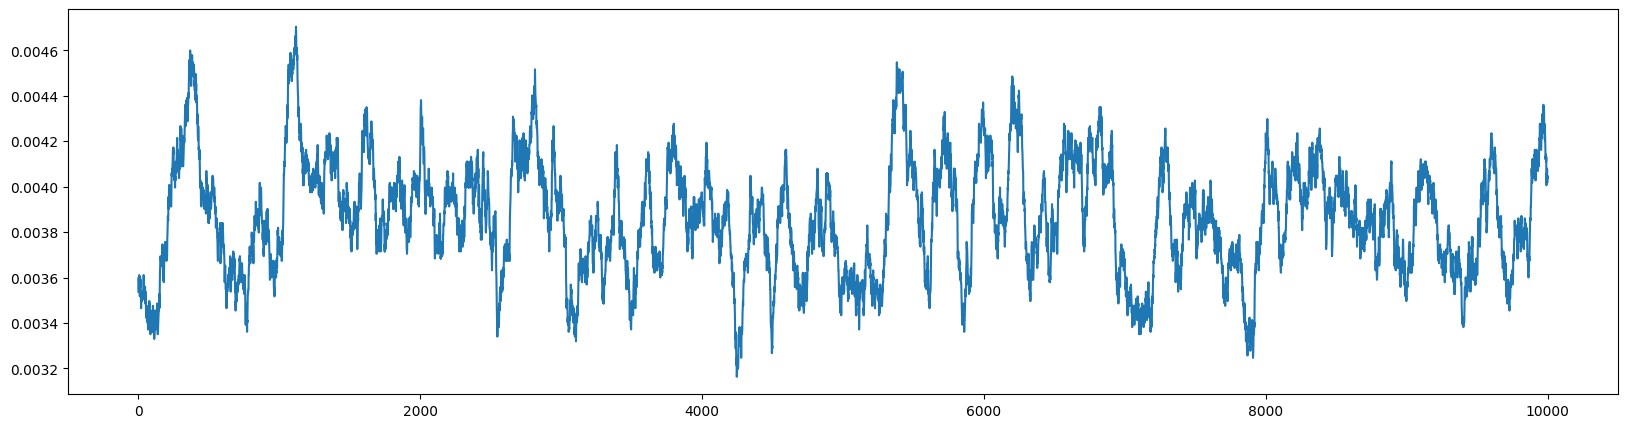

In [89]:
inst_firing_rate = uniform_filter1d(np.mean(spike_trains, axis = 0), 100)
fig, ax = plt.subplots(1, 1, figsize = (20, 5))
plt.plot(inst_firing_rate)


FOOOF WARNING: Skipping frequency == 0, as this causes a problem with fitting.

FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 3.91
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                       The model was run on the frequency range 3 - 200 Hz                        
                                 Frequency Resolution is 3.91 Hz                                  
                                                                         

Text(0.5, 1.0, 'inh_distal_basal')

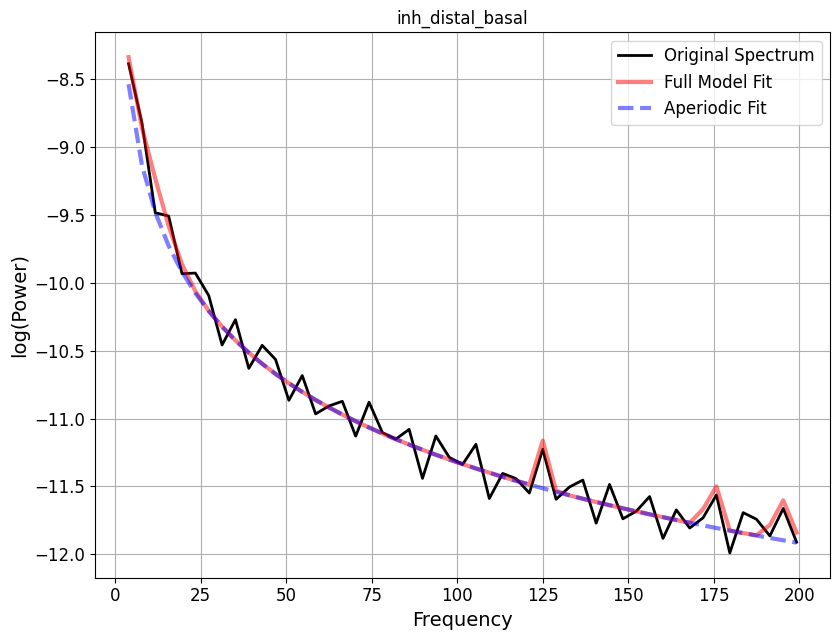

In [90]:
f, Pxx = welch(inst_firing_rate, fs = 1000)
fm = FOOOF()
fm.report(f, Pxx, [0, 200])
plt.title(what)